# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository. The first three columns denote different parameters obtained from the photographs of the banknotes and last colum provides the label. Frankly as the dataset does not have any description I don't know  which labels corresponds to real and which to counterfeited banknotes. let's assume that label one (positive) denotes the clounterfeits. The set  [banknote_authentication.csv](./data/banknote_authentication.csv) can be found in the `data`  directory.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [71]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [72]:
import  matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(8,8)

Please insert you  firstname  and name below

In [73]:
from  sklearn.model_selection import train_test_split
seed = 31287

In [74]:
data = pd.read_csv('data/banknotes_data.csv')

In [75]:
data.head()

,a0,a1,a2,a3,counterfeit
0,-1.1306,1.8458,-1.35750,-1.38060,1
1,-1.1188,3.3357,-1.34550,-1.95730,1
2,2.6719,3.0646,0.37158,0.58619,0
3,-4.1409,3.4619,-0.47841,-3.88790,1
4,1.4507,8.7903,-2.23240,-0.65259,0


In [76]:
data.describe()

,a0,a1,a2,a3,counterfeit
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,0.431116,1.902054,1.426607,-1.220393,0.444254
std,2.845672,5.942260,4.397341,2.101777,0.497096
min,-7.042100,-13.773100,-5.286100,-7.871900,0.000000
25%,-1.770900,-1.916200,-1.664300,-2.466150,0.000000
50%,0.471345,2.408650,0.567365,-0.614450,0.000000
75%,2.816925,6.800675,3.338825,0.394810,1.000000
max,6.824800,12.730200,17.927400,2.449500,1.000000


In [77]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a0           1166 non-null   float64
 1   a1           1166 non-null   float64
 2   a2           1166 non-null   float64
 3   a3           1166 non-null   float64
 4   counterfeit  1166 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 45.7 KB


In [78]:
data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data.loc[:,'counterfeit'], random_state=seed)

In [79]:
data_train

,a0,a1,a2,a3,counterfeit
711,1.94760,-4.773800,8.52700,-1.866800,0
565,1.42760,8.384700,-2.09950,-1.967700,0
912,-4.28590,8.523400,3.13920,-0.916390,0
64,4.92490,0.689060,0.77344,1.209500,0
871,2.19480,1.378100,1.15820,0.857740,0
...,...,...,...,...,...
47,-2.45610,-4.556600,6.45340,-0.056479,1
1161,1.21380,8.798600,-2.16720,-0.741820,0
174,5.87820,5.940900,-2.85440,-0.608630,0
1119,0.17346,7.869500,0.26876,-3.788300,0


In [80]:
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

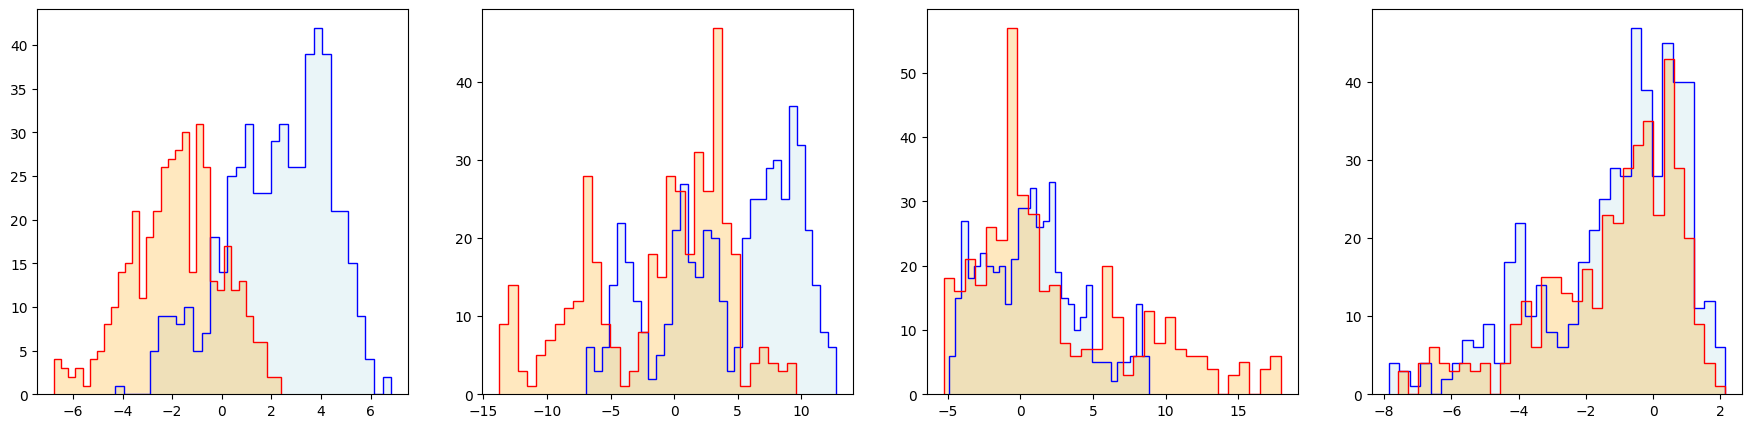

In [81]:
fig, ax = plt.subplots(1,4, figsize=(22,5))
for i in range(4):
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='step', color='blue')
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='step', color='red')
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='bar', color='lightblue', alpha=0.25)
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='bar', color='orange', alpha =0.25)

# Problem 1

Train a neural network classifier to predict counterfeit banknotes. Use the features `a0` and `a3`. Calculate the confussion matrix  and AUC score. 

In [82]:
import torch
import torch.nn as nn
# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
# print(f"Using {device} device") #if NViDIA GPU is available

# class NeuralNetwork(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.flatten = nn.Flatten()
#         self.linear_relu_stack = nn.Sequential(
#             nn.Linear(28*28, 512),
#             nn.ReLU(),
#             nn.Linear(512, 512),
#             nn.ReLU(),
#             nn.Linear(512, 10),
#         )

#     def forward(self, x):
#         x = self.flatten(x)
#         logits = self.linear_relu_stack(x)
#         return logits

# model = NeuralNetwork().to(device)
# print(model)


In [83]:
features= [0, 3] #choose features
nf=len(features) # 2

# X = torch.rand(1, 28, 28, device=device)
# logits = model(X)
# pred_probab = nn.Softmax(dim=1)(logits) #softmax - we want probability 
# y_pred = pred_probab.argmax(1)
# print(f"Predicted class: {y_pred}")

In [84]:
# training

features_train = torch.from_numpy(data_train.values[:,features]).to(dtype=torch.float32)
labels_train = torch.from_numpy(data_train.values[:,4:5]).to(dtype=torch.float32) #selecting only column 4, but keepong it in 2D structure.
print(labels_train[:10]) #so its only matching values like "0" and "1"
print(features_train[:10]) #just passing a0 and a3 feature

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.]])
tensor([[ 1.9476, -1.8668],
        [ 1.4276, -1.9677],
        [-4.2859, -0.9164],
        [ 4.9249,  1.2095],
        [ 2.1948,  0.8577],
        [ 2.2034,  0.8500],
        [ 0.3292, -0.9888],
        [ 3.5458, -3.9564],
        [-1.3660,  1.5806],
        [ 1.7875, -3.2362]])


In [85]:
# test 

features_test = torch.from_numpy(data_test.values[:,features]).to(dtype=torch.float32)
labels_test = torch.from_numpy(data_test.values[:,4:5]).to(dtype=torch.float32)
print(labels_test[:10]) #so its only matching values like "0" and "1"
print(features_test[:10])

tensor([[0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.]])
tensor([[ 5.3063, -0.5272],
        [-2.2987,  0.9172],
        [-3.3553, -0.3785],
        [-3.0799, -0.2375],
        [ 0.5195, -0.9849],
        [-3.5798, -0.4573],
        [-2.9146, -4.0327],
        [-1.3885, -7.5487],
        [ 2.6718, -1.4892],
        [-2.0285, -1.1750]])


In [86]:
# in_features (int) – size of each input sample
# out_features (int) – size of each output sample
model = nn.Sequential(nn.Linear(in_features=nf, out_features=1), nn.Sigmoid())
'''x1 ----\
           >---- [ Linear ] ---- Sigmoid ---- output
   x2 ----/
'''

# y=w_1*​x_1 ​+ w_2*​x_2 ​+ b
# nn.Linear - Applies an affine linear transformation to the incoming data: y=x*A^T + b
# so I basically create perceptron (ツ)


'x1 ----           >---- [ Linear ] ---- Sigmoid ---- output\n   x2 ----/\n'

In [87]:
from sklearn.metrics import roc_curve, confusion_matrix, accuracy_score

In [88]:
y_true = labels_test.numpy()
print(y_true[:5])
print()

with torch.no_grad(): #random weights use
  y_proba = model(features_test);
  y_predicted = 1*(y_proba>0.5) # converts booleans into integers.

# 0.91 > 0.5 → True
# 0.12 > 0.5 → False

# True behaves like 1
# False behaves like 0

[[0.]
 [1.]
 [1.]
 [1.]
 [0.]]



In [89]:
accuracy_score(y_true, y_pred=y_predicted)

0.8589743589743589

In [90]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.001)

In [93]:
loss_fn = nn.BCELoss() #Creates a criterion that measures the Binary Cross Entropy between the target and the input probabilities - Pytorch doc

for era in range(50):
    for epoch in range(500):
        optimizer.zero_grad()
        pred = model(features_train)
        # print(f"pred: {pred.shape}")
        # print(f"pred: {pred[0][0]}")
        # print(f"pred: {pred[0]}")
        # print(f"pred: {pred[:10]}")
        # print()
        # print(f"labels: {labels_train}")
        loss = loss_fn(pred, labels_train) #how well or how bad network performs
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        pred =  model(features_train)
        acc_train =  torch.mean(0.0+ ((pred > 0.5)== (labels_train>0.5)))
        pred =  model(features_test)
        acc_test =  torch.mean(0.0+ ((pred > 0.5)== (labels_test>0.5)))
    print(f"acc_train, acc_test: {acc_train, acc_test}")

# Maybe I've done something wrong and it should be something like this:
'''
nn.Sequential(
    nn.Linear(2,8),
    nn.ReLU(),
    nn.Linear(8,8),
    nn.ReLU(),
    nn.Linear(8,1),
    nn.Sigmoid()
)
'''
# So more alyers 

# I dont get the use of one neuron neural network ¯\_(ツ)_/¯

acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor(0.8734), tensor(0.8803))
acc_train, acc_test: (tensor

'\nnn.Sequential(\n    nn.Linear(2,8),\n    nn.ReLU(),\n    nn.Linear(8,8),\n    nn.ReLU(),\n    nn.Linear(8,1),\n    nn.Sigmoid()\n)\n'